##  AIM

The aim of this project is to analyze financial transaction data using Python, SQL, and statistical techniques to identify fraudulent and anomalous transaction patterns, assess financial risk, and support data-driven fraud monitoring and decision-making.

##  BUSINESS PROBLEM

Financial institutions process thousands of transactions daily, making it difficult to manually detect fraudulent activities and suspicious transaction behavior. Fraudulent transactions can lead to major financial losses, operational risks, and reduced customer trust.

The organization needs a data-driven solution to:

-  Detect anomalous and high-risk transactions

-  Identify suspicious behavioral patterns

-  Monitor fraud-prone regions and transaction activities

-  Improve fraud investigation and risk assessment processes

## OBJECTIVE

- Perform data cleaning and preprocessing on financial transaction datasets using Python.

- Conduct exploratory and statistical analysis to understand transaction behavior.

- Detect anomalous and potentially fraudulent transactions using analytical techniques.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

## DATA LOADING

In [52]:
df= pd.read_csv("AIML Dataset.csv")

In [53]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [55]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [56]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [57]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048575
Name: count, dtype: int64

## CONNECTING TO MYSQL 

In [58]:
## connecting to sql server 
from sqlalchemy import create_engine
import urllib

# Your SQL Server details
server = r"DESKTOP-A98TCB7\SQLEXPRESS"   # Use raw string for backslash
database = "financial_risk_analysis"            # Your database name
driver = "ODBC Driver 17 for SQL Server"   # Must be installed on your machine

# Build connection string for Windows Authentication
connection_string = urllib.parse.quote_plus(
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

# Create engine
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")

print("✔ Successfully connected to SQL Server (Windows Authentication)!") 

✔ Successfully connected to SQL Server (Windows Authentication)!


In [59]:
table_name = "transaction"   # SQL table name you want to create

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"✔ Data successfully loaded into table '{table_name}' in database 'data_analysis_project'.")

✔ Data successfully loaded into table 'transaction' in database 'data_analysis_project'.


## DATA PROCESSING & EDA

In [60]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [61]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [62]:
df.shape

(1048575, 11)

In [63]:
## IsFraud percentage
round((df["isFraud"].value_counts()[1]/df.shape[0]*100),2)

0.11

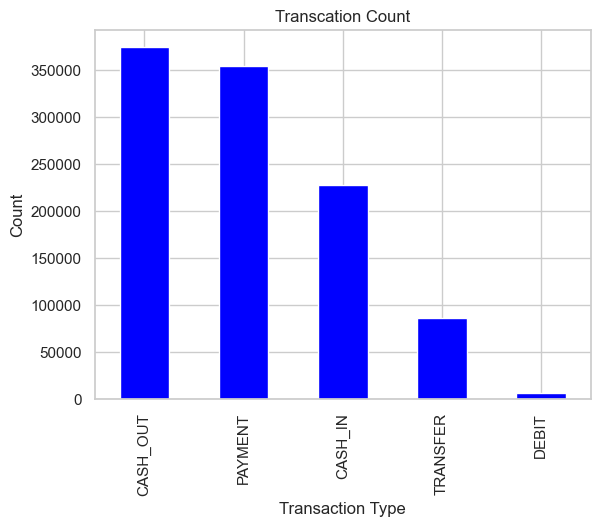

In [64]:
df['type'].value_counts().plot(kind="bar",title="Transcation Count",color="blue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

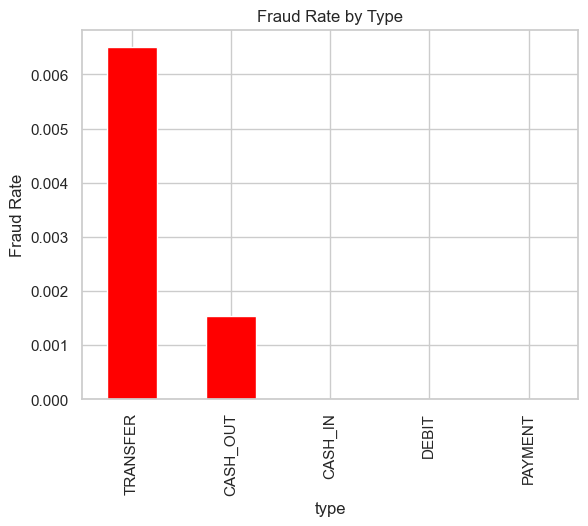

In [65]:
fraud_by_type=df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="Fraud Rate by Type",color="Red")
plt.ylabel("Fraud Rate")
plt.show()

In [66]:
df["amount"].describe().astype(int)

count     1048575
mean       158666
std        264940
min             0
25%         12149
50%         76343
75%        213761
max      10000000
Name: amount, dtype: int32

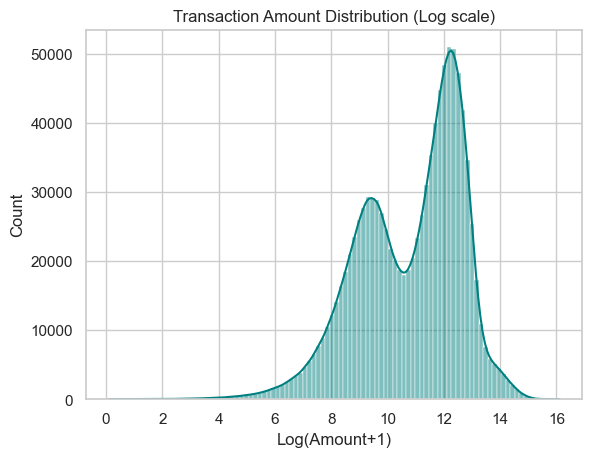

In [67]:
sns.histplot(np.log1p(df["amount"]),bins=100, kde=True, color="Teal")
plt.title("Transaction Amount Distribution (Log scale)")
plt.xlabel("Log(Amount+1)")
plt.show()

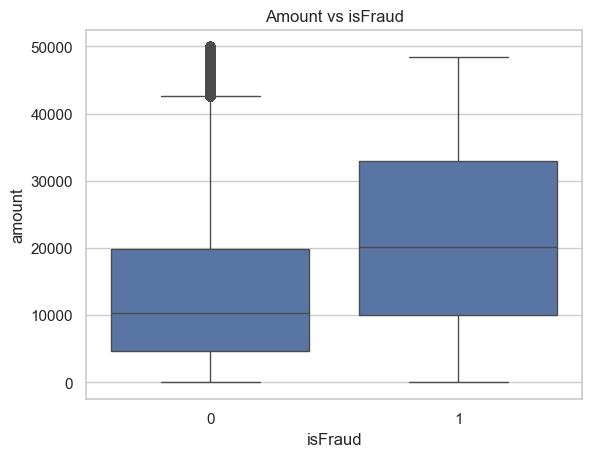

In [68]:
sns.boxplot(data=df[df["amount"]< 50000], x= "isFraud", y="amount")
plt.title("Amount vs isFraud")
plt.show()

In [69]:
## Balance difference
df["balanceDiffOrig"] = ( df["oldbalanceOrg"] - df["newbalanceOrig"])

df["balanceDiffDest"] = (df["newbalanceDest"] - df["oldbalanceDest"])



In [70]:
print((df["balanceDiffOrig"] < 0).sum())


221805


In [71]:
print((df["balanceDiffDest"] < 0).sum())

203566


In [72]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


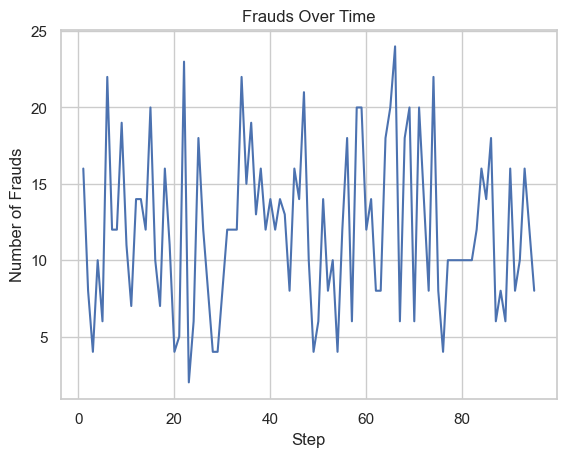

In [73]:
# FRAUDS OVER TIME
frauds_per_step = (df[df["isFraud"] == 1]["step"].value_counts().sort_index())
plt.plot( frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()


In [74]:
# Drop step column
df.drop(columns=["step"], inplace=True)

In [75]:
# TOP SENDERS & RECEIVERS
top_senders = df["nameOrig"].value_counts().head(10)
print(top_senders)

nameOrig
C1214450722    2
C309111136     2
C1268675361    2
C720460198     2
C1109092856    2
C545402485     2
C1362689728    2
C110179857     2
C1467095135    2
C2073023524    2
Name: count, dtype: int64


In [76]:
top_receivers = df["nameDest"].value_counts().head(10)
print(top_receivers)

nameDest
C985934102     98
C1286084959    96
C1590550415    89
C248609774     88
C665576141     87
C2083562754    86
C977993101     82
C1360767589    81
C451111351     80
C306206744     79
Name: count, dtype: int64


In [77]:
# Fraud users
fraud_users = ( df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10))
print(fraud_users)


nameOrig
C1305486145    1
C1776675634    1
C289101217     1
C1116093088    1
C1795901064    1
C1422133318    1
C1694539503    1
C1198248537    1
C1837436553    1
C1422380255    1
Name: count, dtype: int64


In [78]:
# TRANSFER & CASH OUT ANALYSIS
fraud_types = df[ df["type"].isin(["TRANSFER", "CASH_OUT"])]


In [79]:
fraud_types["type"].value_counts()

type
CASH_OUT    373641
TRANSFER     86753
Name: count, dtype: int64

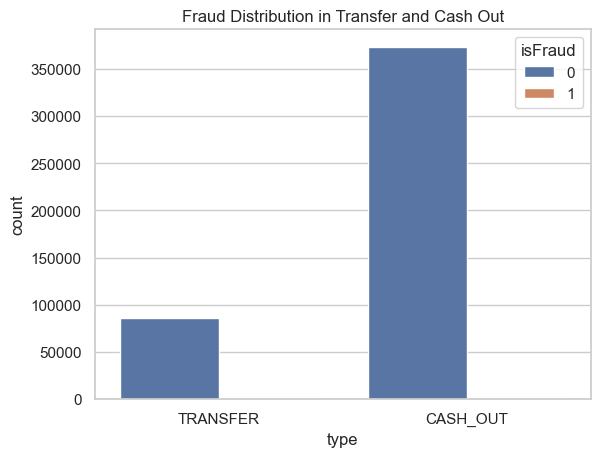

In [80]:
sns.countplot(data=fraud_types,x="type",hue="isFraud")
plt.title("Fraud Distribution in Transfer and Cash Out")
plt.show()

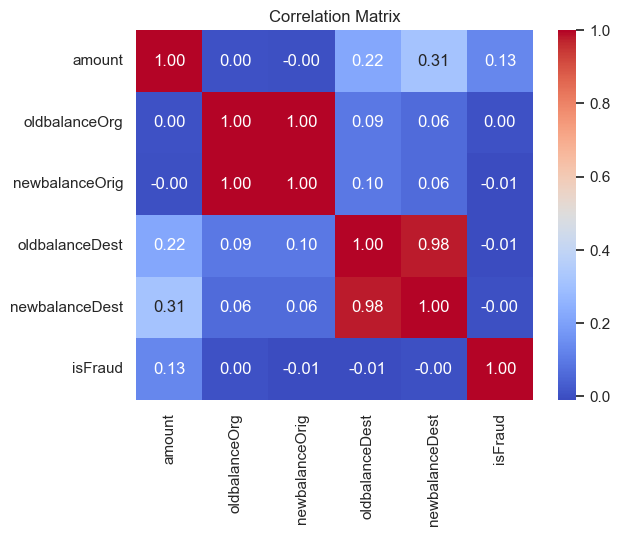

In [81]:
# CORRELATION MATRIX
corr_matrix = df[["amount", "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [82]:
# SUSPICIOUS TRANSACTIONS
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))]

In [83]:
print(len(zero_after_transfer))

192858


In [84]:
## check
zero_after_transfer.head()


,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [85]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

## FEATURE ENGINEERING

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [87]:
# Drop unnecessary columns
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [88]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"],axis=1)

In [89]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [90]:
# Categorical & numerical columns
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]


In [91]:
# Target
y = df_model["isFraud"]

X = df_model.drop("isFraud", axis=1)


In [92]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.3,stratify=y)

In [93]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)


In [94]:
# Pipeline
pipeline = Pipeline([("prep", preprocessor),( "clf",LogisticRegression(class_weight="balanced",
max_iter=1000))])

In [95]:
# Train Model
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
# Predictions
y_pred = pipeline.predict(X_test)

In [97]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    314230
           1       0.02      0.96      0.03       343

    accuracy                           0.94    314573
   macro avg       0.51      0.95      0.50    314573
weighted avg       1.00      0.94      0.97    314573



In [98]:
print(confusion_matrix(y_test, y_pred))

[[293847  20383]
 [    15    328]]


In [99]:
pipeline.score(X_test, y_test)

0.9351565455395091

In [100]:
# SAVE MODEL
import joblib


In [101]:
joblib.dump(
    pipeline,
    "fraud_detection_pipeline.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
